# 4.1 — Prevision de la demande  📈
**Projet Teranga Market — Partie 4 (Modeles)**

## Objectif
Prevoir la **demande quotidienne** (nombre d'unites vendues) pour anticiper les besoins de **stock**.

## Demarche
1. **Preparer** les donnees : construire une serie temporelle par categorie de produit
2. **Explorer** : tendance ? saisonnalite ?
3. **Modeliser** : une *baseline* simple, puis **Prophet**
4. **Ameliorer** : ajouter le calendrier des **promotions**
5. **Evaluer** : MAE, RMSE, MAPE — et comparer les modeles

> On travaille au niveau **categorie** (7 series) : ni trop fin (produit = trop clairseme, ~0,5 vente/jour),
> ni trop global (magasin entier = peu actionnable). C'est le bon niveau pour piloter le stock.

## 0. Imports et configuration

In [1]:
import logging, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
from prophet import Prophet

# Prophet est tres bavard : on coupe ses logs pour y voir clair
logging.getLogger("prophet").setLevel(logging.ERROR)
logging.getLogger("cmdstanpy").setLevel(logging.ERROR)
warnings.simplefilter("ignore")

# Chemin vers l'entrepot DuckDB (2 dossiers au-dessus de ce notebook)
RACINE = Path.cwd().parents[1] if Path.cwd().name == "forecasting" else Path("D:/PROJET_FINAL")
DB = RACINE / "02_DONNEES" / "warehouse" / "teranga.duckdb"
EVAL = RACINE / "03_MODELES" / "evaluation"   # ou seront enregistrees les metriques
EVAL.mkdir(exist_ok=True)
print("Entrepot :", DB, "| existe :", DB.exists())

D:\PROJET_FINAL\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


Entrepot : D:\PROJET_FINAL\02_DONNEES\warehouse\teranga.duckdb | existe : True


## 1. Preparation des donnees
On lit l'entrepot et on agrege les ventes par **jour** et par **categorie**.

On somme la **quantite** (unites vendues) = la "demande" au sens stock (pas le nombre de transactions).

In [2]:
con = duckdb.connect(str(DB), read_only=True)
df = con.execute("""
    SELECT CAST(t.date_vente AS DATE) AS date,
           p.categorie                AS categorie,
           SUM(t.quantite)            AS quantite
    FROM transactions t
    JOIN produits p ON t.id_produit = p.id_produit
    GROUP BY 1, 2
    ORDER BY 2, 1
""").fetchdf()
con.close()
df["date"] = pd.to_datetime(df["date"])
df.head()

,date,categorie,quantite
0,2025-07-01,Accessoires,58.0
1,2025-07-02,Accessoires,43.0
2,2025-07-03,Accessoires,52.0
3,2025-07-04,Accessoires,64.0
4,2025-07-05,Accessoires,56.0


**Attention** : si une categorie n'a eu **aucune vente** un jour, la ligne est absente.
Un modele de serie temporelle a besoin d'un pas de temps **regulier** : on recree ces jours avec `quantite = 0`.

In [3]:
cats = df["categorie"].unique()
plage = pd.date_range(df["date"].min(), df["date"].max(), freq="D")
grille = pd.MultiIndex.from_product([cats, plage], names=["categorie", "date"])
df = (df.set_index(["categorie", "date"]).reindex(grille, fill_value=0).reset_index())
df = df[["date", "categorie", "quantite"]].sort_values(["categorie", "date"])

print(f"{len(df)} lignes = {df['categorie'].nunique()} categories x {df['date'].nunique()} jours")
print(f"Periode : {df['date'].min().date()} -> {df['date'].max().date()}")
df.groupby("categorie")["quantite"].sum().sort_values(ascending=False)

2555 lignes = 7 categories x 365 jours
Periode : 2025-07-01 -> 2026-06-30


categorie
Accessoires                46000.0
Smartphones & tablettes    36006.0
Audio                      23323.0
Objets connectes           10273.0
Gaming                      9839.0
TV & image                  7852.0
Ordinateurs                 7824.0
Name: quantite, dtype: float64

## 2. Exploration visuelle
Avant de modeliser, on regarde : y a-t-il une **tendance** ? une **saisonnalite** ?

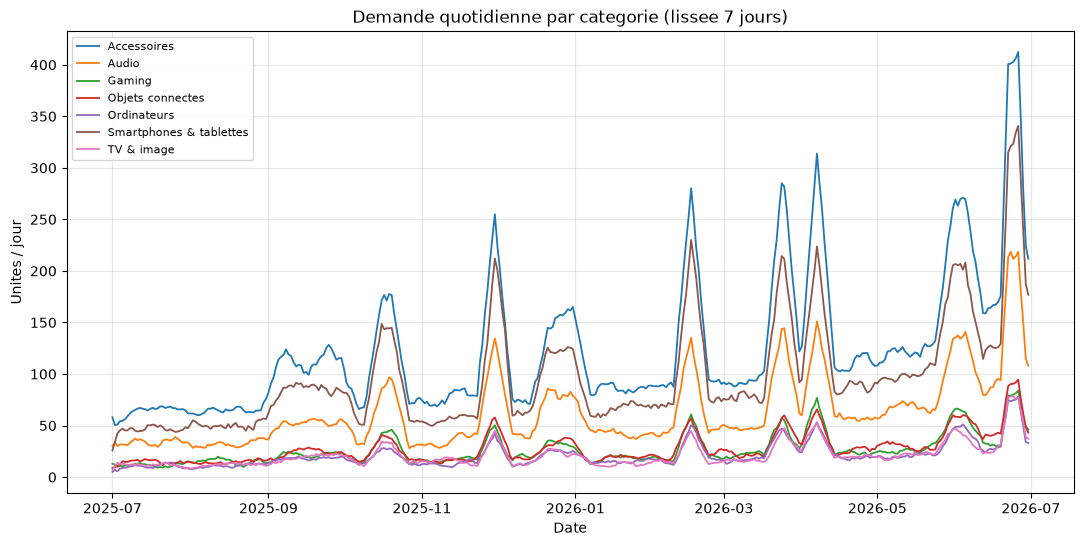

In [4]:
fig, ax = plt.subplots(figsize=(13, 6))
for cat, g in df.groupby("categorie"):
    s = g.set_index("date")["quantite"].rolling(7, min_periods=1).mean()  # lissage 7j
    ax.plot(s.index, s.values, label=cat, linewidth=1.3)
ax.set_title("Demande quotidienne par categorie (lissee 7 jours)")
ax.set_xlabel("Date"); ax.set_ylabel("Unites / jour")
ax.legend(fontsize=8); ax.grid(alpha=0.3); plt.show()

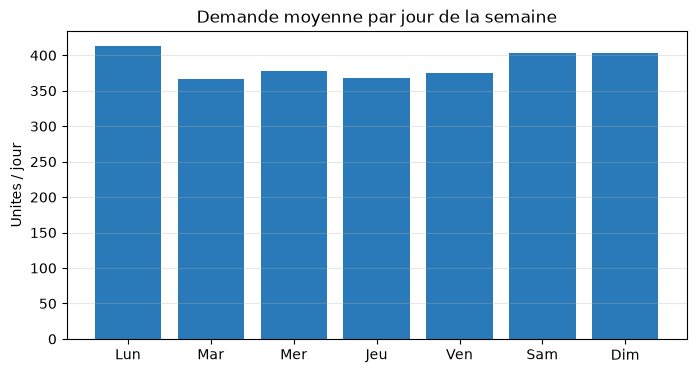

In [5]:
# Saisonnalite hebdomadaire : demande moyenne par jour de la semaine
tot = df.groupby("date")["quantite"].sum().reset_index()
tot["jour"] = tot["date"].dt.dayofweek
noms = ["Lun","Mar","Mer","Jeu","Ven","Sam","Dim"]
moy = tot.groupby("jour")["quantite"].mean()
plt.figure(figsize=(8,4))
plt.bar([noms[i] for i in moy.index], moy.values, color="#2a7ab9")
plt.title("Demande moyenne par jour de la semaine"); plt.ylabel("Unites / jour")
plt.grid(axis="y", alpha=0.3); plt.show()

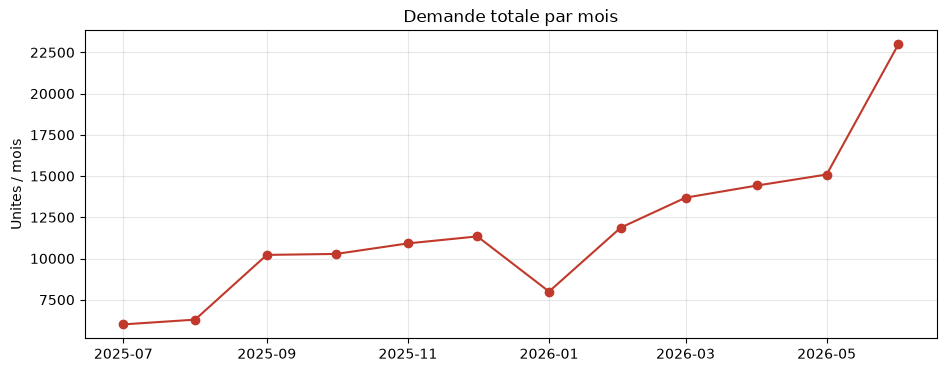

In [6]:
# Tendance mensuelle
tot["mois"] = tot["date"].dt.to_period("M").dt.to_timestamp()
mens = tot.groupby("mois")["quantite"].sum()
plt.figure(figsize=(11,4))
plt.plot(mens.index, mens.values, marker="o", color="#c0392b")
plt.title("Demande totale par mois"); plt.ylabel("Unites / mois")
plt.grid(alpha=0.3); plt.show()

### 💰 Vue business : chiffre d'affaires (CA) par mois
On visualise le **CA** (montant total vendu) — la vraie metrique business — et on **surligne les periodes de
promotion**. Verification de coherence : le CA doit faire un **pic** pendant les promos (demande elastique).

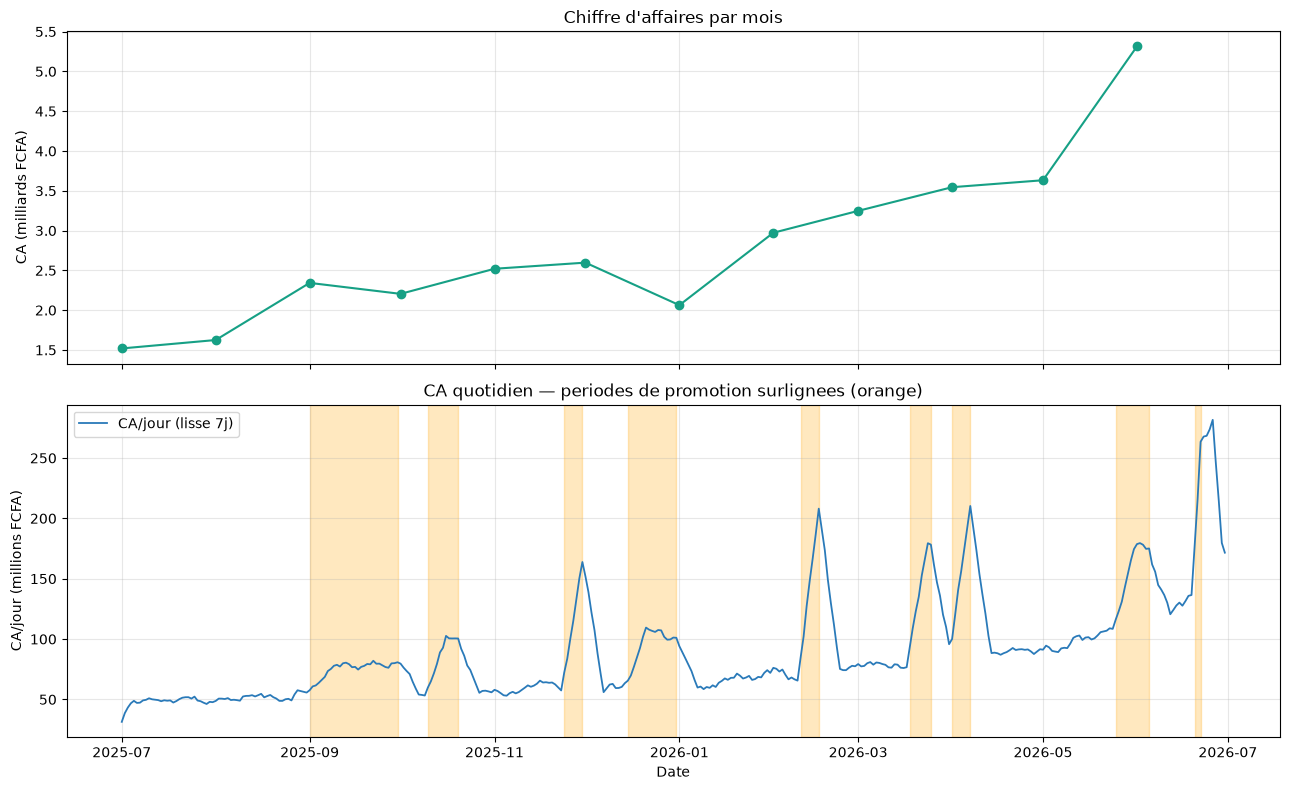

CA moyen/jour  ->  en promo : 138 M   |   hors promo : 74 M   (+87%)


In [7]:
# CA par mois + CA quotidien avec periodes de promo surlignees
con = duckdb.connect(str(DB), read_only=True)
ca_jour = con.execute("""
    SELECT CAST(date_vente AS DATE) date, SUM(montant_total) CA
    FROM transactions GROUP BY 1 ORDER BY 1
""").fetchdf()
promos = con.execute("""
    SELECT nom_campagne, CAST(date_debut AS DATE) d1, CAST(date_fin AS DATE) d2
    FROM promotions WHERE id_promo != 0
""").fetchdf()
con.close()
ca_jour["date"] = pd.to_datetime(ca_jour["date"])
ca_mois = ca_jour.set_index("date")["CA"].resample("MS").sum()

fig, ax = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
# (1) CA par mois (ce que demande l'equipe)
ax[0].plot(ca_mois.index, ca_mois.values/1e9, marker="o", color="#16a085")
ax[0].set_title("Chiffre d'affaires par mois"); ax[0].set_ylabel("CA (milliards FCFA)")
ax[0].grid(alpha=0.3)
# (2) CA quotidien (lisse 7j) + periodes de promo en orange -> on VOIT les pics
s = ca_jour.set_index("date")["CA"].rolling(7, min_periods=1).mean() / 1e6
ax[1].plot(s.index, s.values, color="#2a7ab9", lw=1.3, label="CA/jour (lisse 7j)")
for _, r in promos.iterrows():
    ax[1].axvspan(pd.Timestamp(r.d1), pd.Timestamp(r.d2), color="orange", alpha=0.25)
ax[1].set_title("CA quotidien — periodes de promotion surlignees (orange)")
ax[1].set_ylabel("CA/jour (millions FCFA)"); ax[1].set_xlabel("Date")
ax[1].grid(alpha=0.3); ax[1].legend(loc="upper left")
plt.tight_layout(); plt.show()

# Preuve chiffree de la coherence : CA/jour en promo vs hors promo
ca_jour["promo"] = False
for _, r in promos.iterrows():
    m = (ca_jour["date"] >= pd.Timestamp(r.d1)) & (ca_jour["date"] <= pd.Timestamp(r.d2))
    ca_jour.loc[m, "promo"] = True
moy = ca_jour.groupby("promo")["CA"].mean()
print(f"CA moyen/jour  ->  en promo : {moy[True]/1e6:.0f} M   |   hors promo : {moy[False]/1e6:.0f} M   "
      f"(+{(moy[True]/moy[False]-1)*100:.0f}%)")

### 🔎 Ce qu'on observe
- **Tendance haussiere** nette : le business grandit sur 12 mois
- **Saisonnalite hebdo faible** : peu d'ecart entre les jours
- **Pics periodiques** (~mensuels) : tres probablement des **promotions** → on les integrera a l'etape 4
- **Creux en janvier** (apres les fetes), gros **pic en juin**
- **Coherence promo confirmee** : le CA fait bien un **pic** pendant les zones oranges (**CA/jour quasi double, +~87%**,
  sur les jours de promo) → les promotions boostent le chiffre d'affaires (demande elastique)

➡️ Il faut donc un modele qui gere **tendance + saisonnalite** : c'est le cas de **Prophet**.

## 3. Modelisation : Baseline + Prophet

**Protocole d'evaluation** — on coupe la serie dans le **temps** (jamais au hasard !) :
- **Train** = tout sauf les 30 derniers jours (on apprend sur le passe)
- **Test** = les **30 derniers jours** (on prevoit le "futur", puis on compare au reel)

**Baseline** (le minimum a battre) = *seasonal naive* : la prevision d'un jour = la vraie valeur **7 jours avant**.

**Metriques** : `MAE` (erreur moyenne en unites), `RMSE` (penalise les grosses erreurs), `MAPE` (erreur en %).

In [8]:
HORIZON_TEST = 30

def mae(y, yhat):  return float(np.mean(np.abs(y - yhat)))
def rmse(y, yhat): return float(np.sqrt(np.mean((y - yhat)**2)))
def mape(y, yhat):
    m = y != 0
    return float(np.mean(np.abs((y[m]-yhat[m])/y[m]))*100) if m.any() else np.nan

In [9]:
def prevision_baseline(train, test):
    """Prevision = valeur du meme jour 7 jours avant."""
    serie = pd.concat([train, test]).set_index("ds")["y"]
    return serie.shift(7).loc[test["ds"]].values

def prevision_prophet(train, test):
    m = Prophet(growth="linear", weekly_seasonality=True, yearly_seasonality=False,
                daily_seasonality=False, seasonality_mode="multiplicative")
    m.add_seasonality(name="mensuelle", period=30.5, fourier_order=5)  # capte les pics ~mensuels
    m.fit(train)
    futur = m.make_future_dataframe(periods=HORIZON_TEST, freq="D")
    prev = m.predict(futur).set_index("ds").loc[test["ds"], "yhat"].values
    return np.clip(prev, 0, None)  # pas de demande negative

In [10]:
resultats = []
for cat in sorted(df["categorie"].unique()):
    g = (df[df["categorie"]==cat].rename(columns={"date":"ds","quantite":"y"})
         [["ds","y"]].sort_values("ds").reset_index(drop=True))
    train, test = g.iloc[:-HORIZON_TEST].copy(), g.iloc[-HORIZON_TEST:].copy()
    y = test["y"].values
    yb = prevision_baseline(train, test)
    yp = prevision_prophet(train, test)
    resultats.append({"categorie":cat,
                      "MAE_baseline":round(mae(y,yb),1), "MAE_prophet":round(mae(y,yp),1),
                      "MAPE_baseline_%":round(mape(y,yb),1), "MAPE_prophet_%":round(mape(y,yp),1)})
    print("[OK]", cat)

res = pd.DataFrame(resultats)
res.loc["MOYENNE"] = res.mean(numeric_only=True).round(1); res.loc["MOYENNE","categorie"]="MOYENNE"
res

17:15:47 - cmdstanpy - INFO - Chain [1] start processing


17:15:48 - cmdstanpy - INFO - Chain [1] done processing


17:15:48 - cmdstanpy - INFO - Chain [1] start processing


17:15:48 - cmdstanpy - INFO - Chain [1] done processing


[OK] Accessoires
[OK] Audio


...

[OK] Ordinateurs


17:15:49 - cmdstanpy - INFO - Chain [1] start processing


17:15:49 - cmdstanpy - INFO - Chain [1] done processing


[OK] Smartphones & tablettes
[OK] TV & image


,categorie,MAE_baseline,MAE_prophet,MAPE_baseline_%,MAPE_prophet_%
0,Accessoires,137.4,91.0,50.2,25.4
1,Audio,79.4,51.4,57.6,27.6
2,Gaming,31.7,22.0,58.9,36.8
3,Objets connectes,32.9,23.0,62.0,31.1
4,Ordinateurs,32.3,19.1,89.1,37.2
5,Smartphones & tablettes,118.0,80.2,56.6,31.2
6,TV & image,29.8,17.5,68.9,29.6
MOYENNE,MOYENNE,65.9,43.5,63.3,31.3


➡️ **Prophet bat la baseline sur toutes les categories.** Le MAPE moyen passe d'environ **63 % a ~31 %** : l'erreur est **divisee par deux**.

## 4. Amelioration : integrer les promotions 🎯

En regardant une prevision, on voit que Prophet **rate les gros pics de promo** (ex. "Vente flash mobile" du 20-22 juin, -35 %).
C'est logique : on ne lui a pas dit qu'une promo avait lieu.

**Idee** : le **calendrier des promos est connu a l'avance**. On le donne au modele comme **variable explicative** (regresseur) =
le taux de reduction actif chaque jour. Prophet peut alors "monter" sa prevision les jours de promo.

In [11]:
def calendrier_promo(dates):
    """Pour chaque jour : taux de reduction de la promo active (0 si aucune)."""
    con = duckdb.connect(str(DB), read_only=True)
    promos = con.execute("""SELECT taux_reduction, CAST(date_debut AS DATE) d1,
                                   CAST(date_fin AS DATE) d2
                            FROM promotions WHERE id_promo != 0""").fetchdf()
    con.close()
    taux = pd.Series(0.0, index=dates)
    for _, r in promos.iterrows():
        actif = (dates >= pd.Timestamp(r.d1)) & (dates <= pd.Timestamp(r.d2))
        taux[actif] = np.maximum(taux[actif], r.taux_reduction)
    return pd.DataFrame({"ds": dates, "taux_promo": taux.values})

promo_cal = calendrier_promo(pd.date_range(df["date"].min(), df["date"].max(), freq="D"))
promo_cal[promo_cal["taux_promo"] > 0].head()

,ds,taux_promo
62,2025-09-01,0.15
63,2025-09-02,0.15
64,2025-09-03,0.15
65,2025-09-04,0.15
66,2025-09-05,0.15


In [12]:
def prevision_prophet_promo(train, test, promo_cal):
    m = Prophet(growth="linear", weekly_seasonality=True, yearly_seasonality=False,
                daily_seasonality=False, seasonality_mode="multiplicative")
    m.add_seasonality(name="mensuelle", period=30.5, fourier_order=5)
    m.add_regressor("taux_promo")                       # <-- la nouveaute
    train = train.merge(promo_cal, on="ds", how="left")
    m.fit(train)
    futur = m.make_future_dataframe(periods=HORIZON_TEST, freq="D")
    futur = futur.merge(promo_cal, on="ds", how="left").fillna({"taux_promo":0})
    prev = m.predict(futur).set_index("ds").loc[test["ds"], "yhat"].values
    return np.clip(prev, 0, None)

In [13]:
comp = []
figs = {}
for cat in sorted(df["categorie"].unique()):
    g = (df[df["categorie"]==cat].rename(columns={"date":"ds","quantite":"y"})
         [["ds","y"]].sort_values("ds").reset_index(drop=True))
    train, test = g.iloc[:-HORIZON_TEST].copy(), g.iloc[-HORIZON_TEST:].copy()
    y = test["y"].values
    yb  = prevision_baseline(train, test)
    yp  = prevision_prophet(train, test)
    ypp = prevision_prophet_promo(train, test, promo_cal)
    figs[cat] = (train, test, yp, ypp)
    comp.append({"categorie":cat, "MAE_baseline":round(mae(y,yb),1),
                 "MAE_prophet":round(mae(y,yp),1), "MAE_prophet_promo":round(mae(y,ypp),1)})
    print("[OK]", cat)

comp = pd.DataFrame(comp)
comp.loc["MOY"] = comp.mean(numeric_only=True).round(1); comp.loc["MOY","categorie"]="MOYENNE"

# On enregistre le tableau de metriques (livrable "metrics + baselines" demande par le sujet)
comp.to_csv(EVAL / "metriques_forecasting.csv", index=False)
print("Metriques enregistrees dans :", EVAL / "metriques_forecasting.csv")
comp

17:15:49 - cmdstanpy - INFO - Chain [1] start processing


17:15:49 - cmdstanpy - INFO - Chain [1] done processing


17:15:49 - cmdstanpy - INFO - Chain [1] start processing


17:15:49 - cmdstanpy - INFO - Chain [1] done processing


17:15:49 - cmdstanpy - INFO - Chain [1] start processing


...

[OK] Smartphones & tablettes


17:15:52 - cmdstanpy - INFO - Chain [1] start processing


17:15:52 - cmdstanpy - INFO - Chain [1] done processing


[OK] TV & image
Metriques enregistrees dans : D:\PROJET_FINAL\03_MODELES\evaluation\metriques_forecasting.csv


,categorie,MAE_baseline,MAE_prophet,MAE_prophet_promo
0,Accessoires,137.4,91.0,83.7
1,Audio,79.4,51.4,44.3
2,Gaming,31.7,22.0,15.6
3,Objets connectes,32.9,23.0,17.6
4,Ordinateurs,32.3,19.1,14.9
5,Smartphones & tablettes,118.0,80.2,68.4
6,TV & image,29.8,17.5,16.4
MOY,MOYENNE,65.9,43.5,37.3


On visualise une categorie pour **voir** l'apport du regresseur promo :

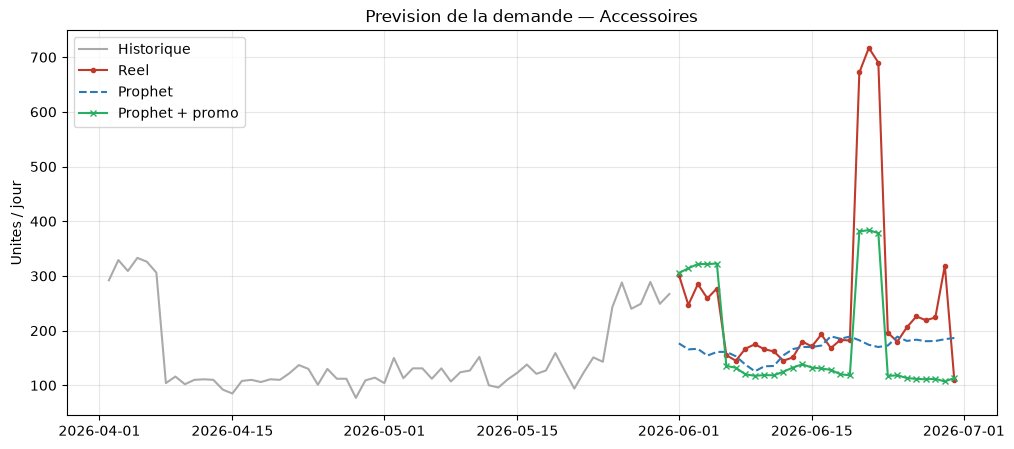

In [14]:
cat = "Accessoires"
train, test, yp, ypp = figs[cat]
plt.figure(figsize=(12,5))
plt.plot(train["ds"].tail(60), train["y"].tail(60), color="#aaa", label="Historique")
plt.plot(test["ds"], test["y"], color="#c0392b", marker="o", ms=3, label="Reel")
plt.plot(test["ds"], yp, color="#2a7ab9", ls="--", label="Prophet")
plt.plot(test["ds"], ypp, color="#27ae60", marker="x", ms=4, label="Prophet + promo")
plt.title(f"Prevision de la demande — {cat}"); plt.ylabel("Unites / jour")
plt.legend(); plt.grid(alpha=0.3); plt.show()

## 5. Conclusion ✅

| Modele | MAE moyen | Lecture |
|---|---|---|
| Baseline (naive 7j) | ~66 | le minimum a battre |
| Prophet | ~43 | **-35 %** vs baseline |
| Prophet + promo | ~37 | **-43 %** vs baseline |

**Ce qu'on retient :**
- Un modele de serie temporelle (Prophet) bat largement une prevision naive.
- Integrer une **connaissance metier** (le calendrier des promotions) ameliore encore la prevision.
- Livrable conforme au sujet : *modeles entraines + evaluation (metrics + baselines)*.

**Prochaine etape** : 4.2 — Optimisation des prix (elasticite prix / demande).